<a href="https://colab.research.google.com/github/SebastianRodriguez05/Teoria_de_Aprendizaje_de_Maquinas-/blob/main/Proyecto_final/TAPNet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import gdown

# ID del archivo desde el enlace compartido de Google Drive
file_id = '1jpW7VNRftEUjVj_yZCOBY6SgA5qa6J4T'

# Ruta local donde se guardará el archivo descargado
output = 'cleaned_music_population.csv'

# Descargar el archivo usando gdown
gdown.download(f'https://drive.google.com/uc?id={file_id}', output, quiet=False)

# Leer el archivo CSV
df = pd.read_csv(output)
df.head()


Downloading...
From: https://drive.google.com/uc?id=1jpW7VNRftEUjVj_yZCOBY6SgA5qa6J4T
To: /content/cleaned_music_population.csv
100%|██████████| 4.12M/4.12M [00:00<00:00, 134MB/s]


,popularity,acousticness,danceability,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,valence,music_genre
0,27.0,0.00468,0.652,0.941,0.79200,A#,0.115,-5.201,Minor,0.0748,100.889,0.759,Electronic
1,31.0,0.01270,0.622,0.890,0.95000,D,0.124,-7.043,Minor,0.0300,115.002,0.531,Electronic
2,28.0,0.00306,0.620,0.755,0.01180,G#,0.534,-4.617,Major,0.0345,127.994,0.333,Electronic
3,34.0,0.02540,0.774,0.700,0.00253,C#,0.157,-4.498,Major,0.2390,128.014,0.270,Electronic
4,32.0,0.00465,0.638,0.587,0.90900,F#,0.157,-6.266,Major,0.0413,145.036,0.323,Electronic


In [ ]:
# Crear etiquetas de clasificación: baja (0), media (1), alta (2)
df['pop_class'] = pd.qcut(df['popularity'], q=3, labels=[0, 1, 2]).astype(int)
df['pop_class'].value_counts()


,count
pop_class,
1,15177
0,15051
2,14792


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import numpy as np

# X: todas las columnas menos la de popularidad original y la clase
X = df.drop(columns=['popularity', 'pop_class'])
y = df['pop_class']

# 🔁 Codificar variables categóricas automáticamente
X_encoded = pd.get_dummies(X)

# 🧼 Escalamiento
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)

# ✂️ División entrenamiento / prueba
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42)


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class FeatureExtractor(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, output_dim=32):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        return self.fc2(x)

class TAPNet(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.feat_extractor = FeatureExtractor(input_dim)
        self.num_classes = num_classes

    def forward(self, x):
        features = self.feat_extractor(x)
        return features


In [ ]:
from torch.utils.data import TensorDataset, DataLoader

# Convertir datos a tensores
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)


In [ ]:
# Inicializar modelo, optimizador y función de pérdida
input_dim = X_train.shape[1]
num_classes = len(np.unique(y))
model = TAPNet(input_dim=input_dim, num_classes=num_classes)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.CrossEntropyLoss()


In [ ]:
def get_prototypes(model, X, y, num_classes):
    model.eval()
    with torch.no_grad():
        features = model(X)
    prototypes = []
    for c in range(num_classes):
        class_features = features[y == c]
        proto = class_features.mean(dim=0)
        prototypes.append(proto)
    return torch.stack(prototypes)

def compute_logits(features, prototypes):
    # Distancia euclidiana negativa como similitud
    dists = torch.cdist(features, prototypes)
    return -dists


In [ ]:
# Entrenar TAPNet
model.train()
for epoch in range(30):
    epoch_loss = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        features = model(X_batch)
        prototypes = get_prototypes(model, X_train_tensor, y_train_tensor, num_classes)
        logits = compute_logits(features, prototypes)
        loss = loss_fn(logits, y_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    print(f"Epoch {epoch+1} - Loss: {epoch_loss:.4f}")


Epoch 1 - Loss: 766.2735
Epoch 2 - Loss: 755.6477
Epoch 3 - Loss: 754.3457
Epoch 4 - Loss: 751.5819
Epoch 5 - Loss: 751.6513
Epoch 6 - Loss: 753.0084
Epoch 7 - Loss: 749.5259
Epoch 8 - Loss: 751.7376
Epoch 9 - Loss: 764.7919
Epoch 10 - Loss: 754.3270
Epoch 11 - Loss: 752.5771
Epoch 12 - Loss: 753.9492
Epoch 13 - Loss: 759.3222
Epoch 14 - Loss: 755.3971
Epoch 15 - Loss: 757.4231
Epoch 16 - Loss: 767.3864
Epoch 17 - Loss: 755.6842
Epoch 18 - Loss: 755.6375
Epoch 19 - Loss: 751.5528
Epoch 20 - Loss: 757.7595
Epoch 21 - Loss: 751.0841
Epoch 22 - Loss: 750.6716
Epoch 23 - Loss: 754.5814
Epoch 24 - Loss: 756.0240
Epoch 25 - Loss: 754.4845
Epoch 26 - Loss: 761.9564
Epoch 27 - Loss: 754.0450
Epoch 28 - Loss: 757.7213
Epoch 29 - Loss: 749.0282
Epoch 30 - Loss: 746.6640


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Evaluar en test
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.long)

model.eval()
with torch.no_grad():
    test_features = model(X_test_tensor)
    test_prototypes = get_prototypes(model, X_train_tensor, y_train_tensor, num_classes)
    test_logits = compute_logits(test_features, test_prototypes)
    y_pred = torch.argmax(test_logits, dim=1)

print(classification_report(y_test_tensor, y_pred))


In [ ]:
# Matriz de confusión
cm = confusion_matrix(y_test_tensor, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Baja', 'Media', 'Alta'], yticklabels=['Baja', 'Media', 'Alta'])
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión - TAPNet")
plt.show()


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# Red que extrae representaciones de los datos
class FeatureExtractor(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, output_dim=32):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        return self.fc2(x)

# Modelo TAPNet: extrae características y luego usa prototipos por clase
class TAPNet(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.feat_extractor = FeatureExtractor(input_dim)
        self.num_classes = num_classes

    def forward(self, x):
        features = self.feat_extractor(x)
        return features


In [ ]:
from torch.utils.data import TensorDataset, DataLoader

# Convertir arrays de NumPy a tensores de PyTorch
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)

# Crear Dataset y DataLoader
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)


In [ ]:
# Definir dimensiones
input_dim = X_train.shape[1]
num_classes = len(np.unique(y))

# Crear modelo
model = TAPNet(input_dim=input_dim, num_classes=num_classes)

# Optimizador y función de pérdida
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.CrossEntropyLoss()


In [ ]:
# Calcular los prototipos por clase
def get_prototypes(model, X_tensor, y_tensor, num_classes):
    model.eval()
    with torch.no_grad():
        features = model(X_tensor)
    prototypes = []
    for c in range(num_classes):
        class_features = features[y_tensor == c]
        proto = class_features.mean(dim=0)
        prototypes.append(proto)
    return torch.stack(prototypes)

# Calcular logits a partir de distancias a prototipos
def compute_logits(features, prototypes):
    # Distancia euclidiana negativa como logits (mayor = más parecido)
    dists = torch.cdist(features, prototypes)
    return -dists


In [ ]:
# Entrenar el modelo TAPNet
epochs = 30
model.train()

for epoch in range(epochs):
    epoch_loss = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()

        # Forward: obtener features
        features = model(X_batch)

        # Prototipos con todo el set de entrenamiento
        prototypes = get_prototypes(model, X_train_tensor, y_train_tensor, num_classes)

        # Calcular distancias y logits
        logits = compute_logits(features, prototypes)

        # Calcular pérdida
        loss = loss_fn(logits, y_batch)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs} - Loss: {epoch_loss:.4f}")

Epoch 1/30 - Loss: 793.5734
Epoch 2/30 - Loss: 765.3151
Epoch 3/30 - Loss: 757.6509
Epoch 4/30 - Loss: 763.1168
Epoch 5/30 - Loss: 762.3069
Epoch 6/30 - Loss: 757.1012
Epoch 7/30 - Loss: 752.9133
Epoch 8/30 - Loss: 755.6570
Epoch 9/30 - Loss: 763.0455
Epoch 10/30 - Loss: 752.4293
Epoch 11/30 - Loss: 749.5108
Epoch 12/30 - Loss: 755.8501
Epoch 13/30 - Loss: 748.9151
Epoch 14/30 - Loss: 747.6232
Epoch 15/30 - Loss: 754.3115
Epoch 16/30 - Loss: 750.0727
Epoch 17/30 - Loss: 756.0329
Epoch 18/30 - Loss: 750.1311
Epoch 19/30 - Loss: 743.1932
Epoch 20/30 - Loss: 750.7037
Epoch 21/30 - Loss: 758.8459
Epoch 22/30 - Loss: 757.4605
Epoch 23/30 - Loss: 754.9621
Epoch 24/30 - Loss: 757.0686
Epoch 25/30 - Loss: 758.1025
Epoch 26/30 - Loss: 758.0723
Epoch 27/30 - Loss: 753.7025
Epoch 28/30 - Loss: 761.9706
Epoch 29/30 - Loss: 754.8752
Epoch 30/30 - Loss: 752.3647


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Preparar datos de test
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.long)

# Evaluar el modelo
model.eval()
with torch.no_grad():
    test_features = model(X_test_tensor)
    test_prototypes = get_prototypes(model, X_train_tensor, y_train_tensor, num_classes)
    test_logits = compute_logits(test_features, test_prototypes)
    y_pred = torch.argmax(test_logits, dim=1)


In [ ]:
print("🔍 Classification Report:\n")
print(classification_report(y_test_tensor, y_pred, target_names=["Baja", "Media", "Alta"]))


🔍 Classification Report:

              precision    recall  f1-score   support

        Baja       0.72      0.83      0.77      3010
       Media       0.61      0.56      0.59      3036
        Alta       0.82      0.76      0.79      2958

    accuracy                           0.72      9004
   macro avg       0.72      0.72      0.72      9004
weighted avg       0.72      0.72      0.71      9004



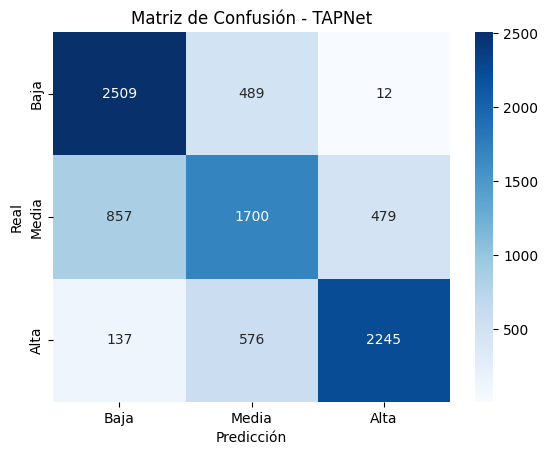

In [ ]:
cm = confusion_matrix(y_test_tensor, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Baja', 'Media', 'Alta'],
            yticklabels=['Baja', 'Media', 'Alta'])

plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión - TAPNet")
plt.show()


In [ ]:
# Obtener las features del test con el modelo entrenado
model.eval()
with torch.no_grad():
    embeddings = model(X_test_tensor).numpy()
    labels = y_test_tensor.numpy()


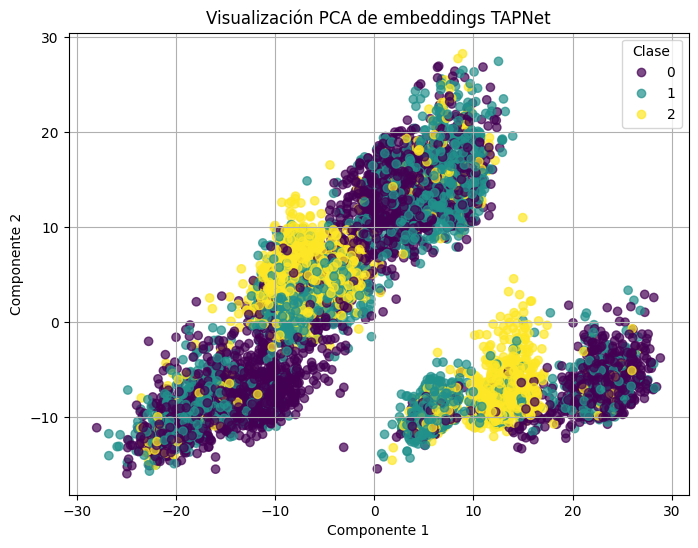

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_result = pca.fit_transform(embeddings)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(pca_result[:, 0], pca_result[:, 1], c=labels, cmap='viridis', alpha=0.7)
plt.legend(*scatter.legend_elements(), title="Clase")
plt.title("Visualización PCA de embeddings TAPNet")
plt.xlabel("Componente 1")
plt.ylabel("Componente 2")
plt.grid(True)
plt.show()


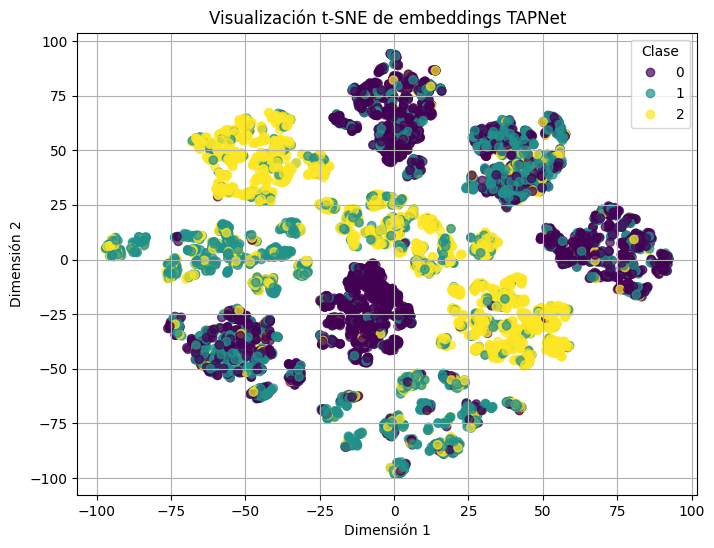

In [ ]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
tsne_result = tsne.fit_transform(embeddings)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(tsne_result[:, 0], tsne_result[:, 1], c=labels, cmap='viridis', alpha=0.7)
plt.legend(*scatter.legend_elements(), title="Clase")
plt.title("Visualización t-SNE de embeddings TAPNet")
plt.xlabel("Dimensión 1")
plt.ylabel("Dimensión 2")
plt.grid(True)
plt.show()
